In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df= pd.read_csv("D:\OneDrive\Desktop\DATA SCIENCE + ML PROJS\datasets\Banking.csv")

<>:1: SyntaxWarning: invalid escape sequence '\O'
<>:1: SyntaxWarning: invalid escape sequence '\O'
C:\Users\Shravan Kundap\AppData\Local\Temp\ipykernel_35928\3032249644.py:1: SyntaxWarning: invalid escape sequence '\O'
  df= pd.read_csv("D:\OneDrive\Desktop\DATA SCIENCE + ML PROJS\datasets\Banking.csv")


END GOAL - SHOW RISK ANALYSIS AND EDA

In [3]:
df.shape

(3000, 25)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Client ID                 3000 non-null   object 
 1   Name                      3000 non-null   object 
 2   Age                       3000 non-null   int64  
 3   Location ID               3000 non-null   int64  
 4   Joined Bank               3000 non-null   object 
 5   Banking Contact           3000 non-null   object 
 6   Nationality               3000 non-null   object 
 7   Occupation                3000 non-null   object 
 8   Fee Structure             3000 non-null   object 
 9   Loyalty Classification    3000 non-null   object 
 10  Estimated Income          3000 non-null   float64
 11  Superannuation Savings    3000 non-null   float64
 12  Amount of Credit Cards    3000 non-null   int64  
 13  Credit Card Balance       3000 non-null   float64
 14  Bank Loa

#Converting the estimated income  into income categories

<Axes: xlabel='Income Band'>

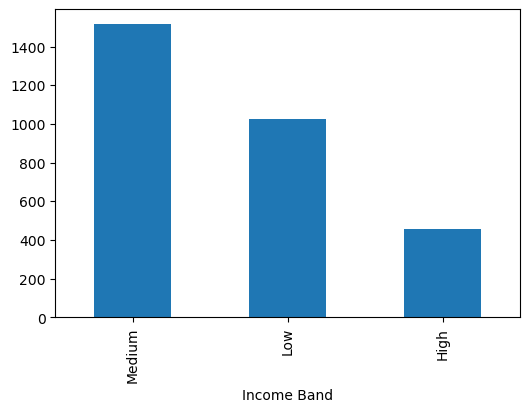

In [5]:
bins=[0,100000,300000,float('inf')]
labels=["Low","Medium","High"]
df["Income Band"]=pd.cut(df['Estimated Income'],bins=bins,labels=labels,right=False)
plt.figure(figsize=(6,4))
df["Income Band"].value_counts().plot(kind="bar")

In [6]:
df.columns

Index(['Client ID', 'Name', 'Age', 'Location ID', 'Joined Bank',
       'Banking Contact', 'Nationality', 'Occupation', 'Fee Structure',
       'Loyalty Classification', 'Estimated Income', 'Superannuation Savings',
       'Amount of Credit Cards', 'Credit Card Balance', 'Bank Loans',
       'Bank Deposits', 'Checking Accounts', 'Saving Accounts',
       'Foreign Currency Account', 'Business Lending', 'Properties Owned',
       'Risk Weighting', 'BRId', 'GenderId', 'IAId', 'Income Band'],
      dtype='object')

In [7]:
df.head()

,Client ID,Name,Age,Location ID,Joined Bank,Banking Contact,Nationality,Occupation,Fee Structure,Loyalty Classification,...,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId,Income Band
0,IND81288,Raymond Mills,24,34324,06-05-2019,Anthony Torres,American,Safety Technician IV,High,Jade,...,603617.88,607332.46,12249.96,1134475.30,1,2,1,1,1,Low
1,IND65833,Julia Spencer,23,42205,10-12-2001,Jonathan Hawkins,African,Software Consultant,High,Jade,...,229521.37,344635.16,61162.31,2000526.10,1,3,2,1,2,Medium
2,IND47499,Stephen Murray,27,7314,25-01-2010,Anthony Berry,European,Help Desk Operator,High,Gold,...,652674.69,203054.35,79071.78,548137.58,1,3,3,2,3,Medium
3,IND72498,Virginia Garza,40,34594,28-03-2019,Steve Diaz,American,Geologist II,Mid,Silver,...,1048157.49,234685.02,57513.65,1148402.29,0,4,4,1,4,High
4,IND60181,Melissa Sanders,46,41269,20-07-2012,Shawn Long,American,Assistant Professor,Mid,Platinum,...,446644.25,128351.45,30012.14,1674412.12,0,3,1,2,5,Medium


In [8]:
df["Gender"] = df["GenderId"].map({
    1: "Male",
    2: "Female"
})
df["Gender"].head()

0      Male
1      Male
2    Female
3      Male
4    Female
Name: Gender, dtype: object

In [14]:
df=df.drop(columns=["GenderId"])

In [10]:
df["Banking Relationship"]=df["BRId"].map({
    1:"Retail",
    2:"Institutional",
    3:"Private Bank",
    4:"Commercial"
})
df["Banking Relationship"].head()

0           Retail
1    Institutional
2     Private Bank
3       Commercial
4           Retail
Name: Banking Relationship, dtype: object

In [ ]:
df=df.drop(columns="BRId")

In [17]:
df=df.drop(columns="IAId")
df.columns

Index(['Client ID', 'Name', 'Age', 'Location ID', 'Joined Bank',
       'Banking Contact', 'Nationality', 'Occupation', 'Fee Structure',
       'Loyalty Classification', 'Estimated Income', 'Superannuation Savings',
       'Amount of Credit Cards', 'Credit Card Balance', 'Bank Loans',
       'Bank Deposits', 'Checking Accounts', 'Saving Accounts',
       'Foreign Currency Account', 'Business Lending', 'Properties Owned',
       'Risk Weighting', 'Income Band', 'Gender', 'Banking Relationship'],
      dtype='object')

In [20]:
df.describe()

,Age,Location ID,Estimated Income,Superannuation Savings,Amount of Credit Cards,Credit Card Balance,Bank Loans,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03,3000.000000,3.000000e+03,3000.000000,3000.000000
mean,51.039667,21563.323000,171305.034263,25531.599673,1.463667,3176.206943,5.913862e+05,6.715602e+05,3.210929e+05,2.329084e+05,29883.529993,8.667598e+05,1.518667,2.249333
std,19.854760,12462.273017,111935.808209,16259.950770,0.676387,2497.094709,4.575570e+05,6.457169e+05,2.820796e+05,2.300078e+05,23109.924010,6.412303e+05,1.102145,1.131191
min,17.000000,12.000000,15919.480000,1482.030000,1.000000,1.170000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,45.000000,0.000000e+00,0.000000,1.000000
25%,34.000000,10803.500000,82906.595000,12513.775000,1.000000,1236.630000,2.396281e+05,2.044004e+05,1.199475e+05,7.479440e+04,11916.542500,3.748251e+05,1.000000,1.000000
50%,51.000000,21129.500000,142313.480000,22357.355000,1.000000,2560.805000,4.797934e+05,4.633165e+05,2.428157e+05,1.640866e+05,24341.190000,7.113147e+05,2.000000,2.000000
75%,69.000000,32054.500000,242290.305000,35464.740000,2.000000,4522.632500,8.258130e+05,9.427546e+05,4.348749e+05,3.155750e+05,41966.392500,1.185110e+06,2.000000,3.000000
max,85.000000,43369.000000,522330.260000,75963.900000,3.000000,13991.990000,2.667557e+06,3.890598e+06,1.969923e+06,1.724118e+06,124704.870000,3.825962e+06,3.000000,5.000000


1. What is the age distribution of bank customers?

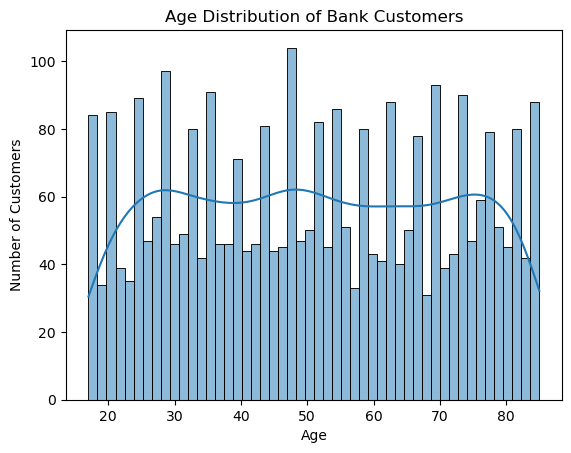

In [24]:
sns.histplot(df["Age"],bins=50,kde=True)
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.title("Age Distribution of Bank Customers")
plt.show()

What is the gender distribution of customers?

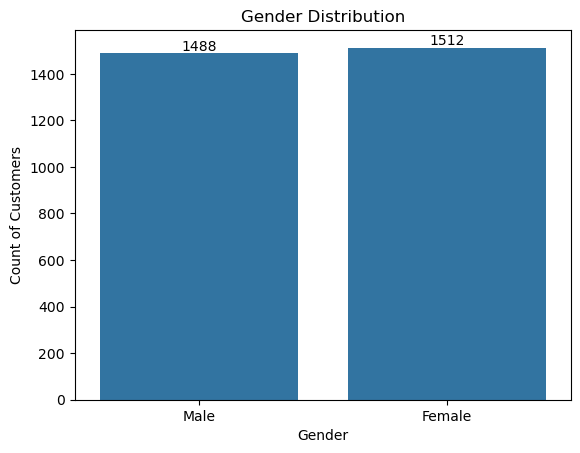

In [32]:
ax=sns.countplot(x=df["Gender"])
ax.bar_label(ax.containers[0])
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count of Customers")
plt.show()

3. Which occupations have the highest number of customers?

In [41]:
cust_by_occu=df.groupby("Occupation")["Client ID"].count().reset_index(0)
cust_by_occu=cust_by_occu.sort_values(by='Client ID',ascending=False)
cust_by_occu.head(10)

,Occupation,Client ID
173,Structural Analysis Engineer,28
25,Associate Professor,28
132,Recruiter,25
0,Account Coordinator,24
93,Human Resources Manager,24
95,Internal Auditor,23
52,Database Administrator II,23
53,Database Administrator III,23
55,Dental Hygienist,23
24,Assistant Professor,23


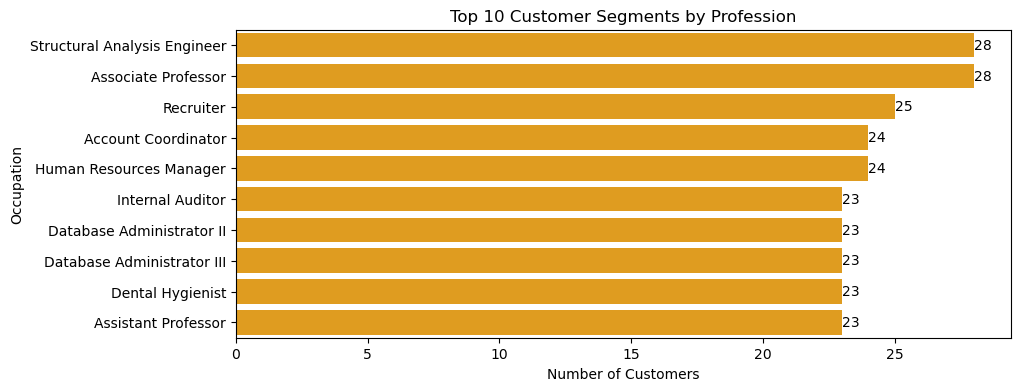

In [40]:
plt.figure(figsize=(10,4))
ax=sns.barplot(cust_by_occu.head(10),x='Client ID',y='Occupation',color='orange')
ax.bar_label(ax.containers[0])
plt.xlabel("Number of Customers")
plt.ylabel("Occupation")
plt.title("Top 10 Customer Segments by Profession")
plt.show()

4. Which nationalities contribute the most customers?

In [48]:
cust_by_nations=df.groupby("Nationality")["Client ID"].count().sort_values(ascending=False).reset_index(0)
cust_by_nations.columns=["Nationality",'No of Clients']
cust_by_nations

,Nationality,No of Clients
0,European,1309
1,Asian,754
2,American,507
3,Australian,254
4,African,176


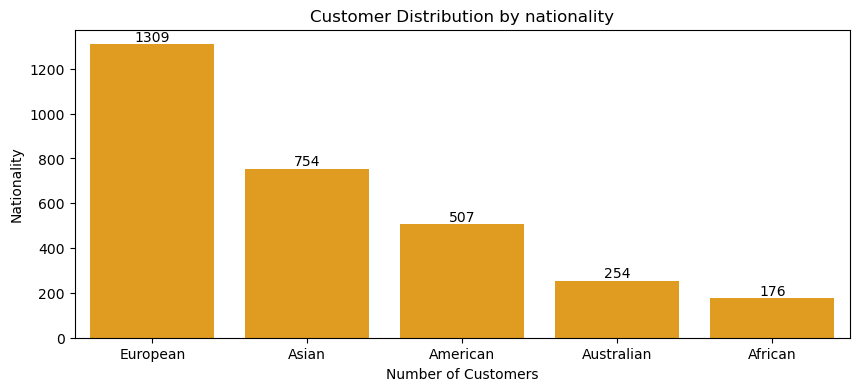

In [49]:
plt.figure(figsize=(10,4))
ax=sns.barplot(cust_by_nations.head(10),x='Nationality',y='No of Clients',color='orange')
ax.bar_label(ax.containers[0])
plt.xlabel("Number of Customers")
plt.ylabel("Nationality")
plt.title("Customer Distribution by nationality")
plt.show()

In [50]:
df.columns

Index(['Client ID', 'Name', 'Age', 'Location ID', 'Joined Bank',
       'Banking Contact', 'Nationality', 'Occupation', 'Fee Structure',
       'Loyalty Classification', 'Estimated Income', 'Superannuation Savings',
       'Amount of Credit Cards', 'Credit Card Balance', 'Bank Loans',
       'Bank Deposits', 'Checking Accounts', 'Saving Accounts',
       'Foreign Currency Account', 'Business Lending', 'Properties Owned',
       'Risk Weighting', 'Income Band', 'Gender', 'Banking Relationship'],
      dtype='object')

5. Which banking relationship type has the most customers?

In [52]:
bankrel_cust=df.groupby("Banking Relationship")["Client ID"].count().sort_values(ascending=False).reset_index(0)
bankrel_cust

,Banking Relationship,Client ID
0,Private Bank,1352
1,Retail,660
2,Institutional,495
3,Commercial,493


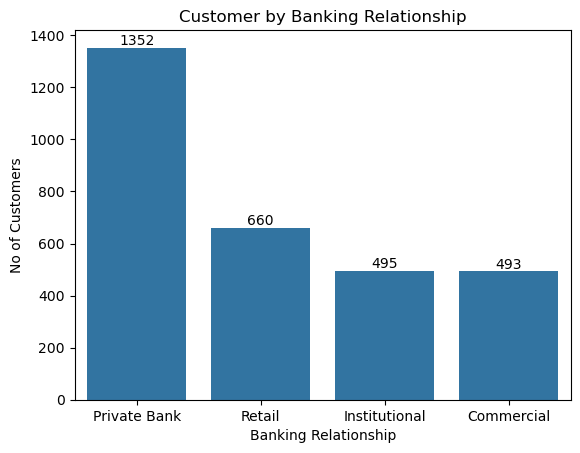

In [58]:
ax=sns.barplot(bankrel_cust,x='Banking Relationship',y='Client ID')
ax.bar_label(ax.containers[0])
plt.ylabel("No of Customers")
plt.title("Customer by Banking Relationship")
plt.show()

6. What is the average number of credit cards owned by customers?

In [59]:
print(df['Amount of Credit Cards'].mean())

1.4636666666666667


7.What is the distribution of estimated income?

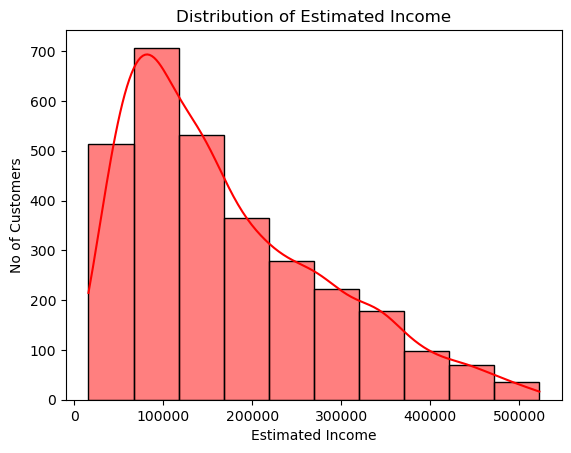

In [62]:
sns.histplot(df["Estimated Income"],bins=10,kde=True,color='red')
plt.xlabel("Estimated Income")
plt.ylabel("No of Customers")
plt.title("Distribution of Estimated Income")
plt.show()

8.Which income band has the highest average bank deposits?

In [65]:
high_dep_avg=df.groupby("Income Band")["Bank Deposits"].mean().sort_values(ascending=False).reset_index(0)
high_dep_avg

C:\Users\Shravan Kundap\AppData\Local\Temp\ipykernel_35928\3955122361.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  high_dep_avg=df.groupby("Income Band")["Bank Deposits"].mean().sort_values(ascending=False).reset_index(0)


,Income Band,Bank Deposits
0,High,929822.363925
1,Medium,719400.462544
2,Low,486223.059533


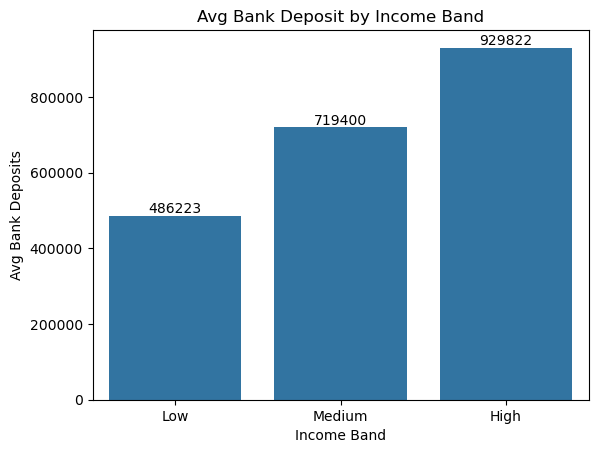

In [70]:
ax=sns.barplot(high_dep_avg,x='Income Band',y='Bank Deposits')
ax.bar_label(ax.containers[0])
plt.ylabel("Avg Bank Deposits")
plt.title("Avg Bank Deposit by Income Band")
plt.show()

9.How does estimated income relate to bank deposits?

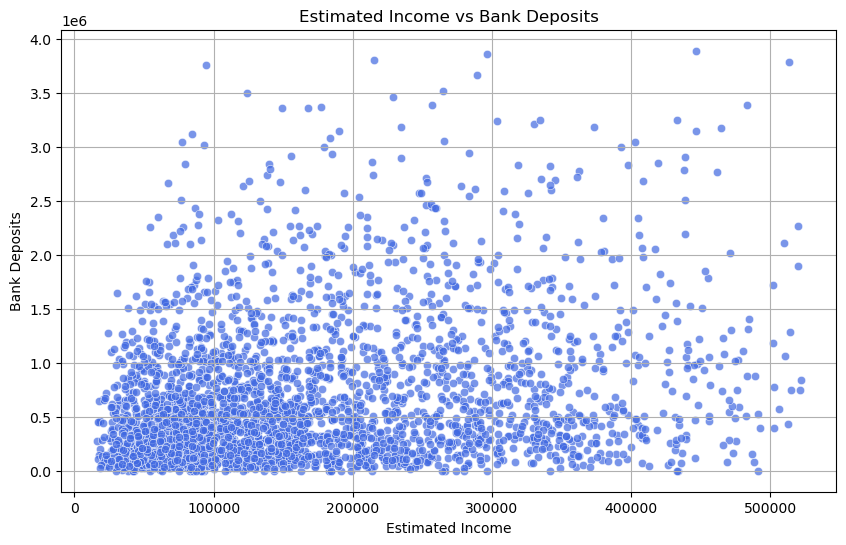

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x="Estimated Income",
    y="Bank Deposits",
    alpha=0.7,
    color="royalblue"
)
plt.title("Estimated Income vs Bank Deposits")
plt.xlabel("Estimated Income")
plt.ylabel("Bank Deposits")
plt.grid(True)
plt.show()

In [78]:
df.columns

Index(['Client ID', 'Name', 'Age', 'Location ID', 'Joined Bank',
       'Banking Contact', 'Nationality', 'Occupation', 'Fee Structure',
       'Loyalty Classification', 'Estimated Income', 'Superannuation Savings',
       'Amount of Credit Cards', 'Credit Card Balance', 'Bank Loans',
       'Bank Deposits', 'Checking Accounts', 'Saving Accounts',
       'Foreign Currency Account', 'Business Lending', 'Properties Owned',
       'Risk Weighting', 'Income Band', 'Gender', 'Banking Relationship'],
      dtype='object')

10.Which income band has the highest average credit card balance?

In [79]:
high_cred_bal= df.groupby("Income Band")["Credit Card Balance"].mean().sort_values(ascending=False).reset_index(0)
high_cred_bal

C:\Users\Shravan Kundap\AppData\Local\Temp\ipykernel_35928\3214313226.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  high_cred_bal= df.groupby("Income Band")["Credit Card Balance"].mean().sort_values(ascending=False).reset_index(0)


,Income Band,Credit Card Balance
0,High,4478.079057
1,Medium,3345.045485
2,Low,2348.766095


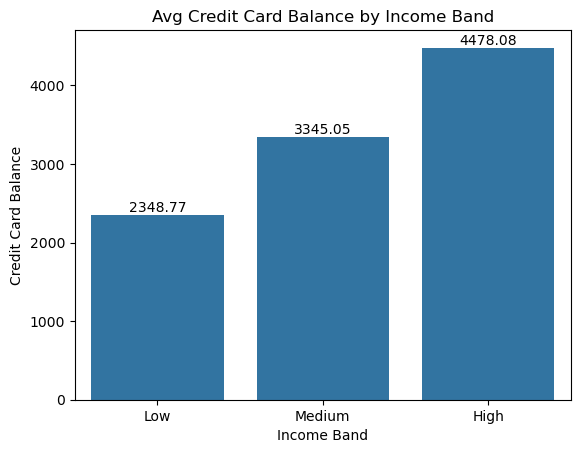

In [84]:
ax=sns.barplot(high_cred_bal,x="Income Band",y="Credit Card Balance")
ax.bar_label(ax.containers[0])
plt.title("Avg Credit Card Balance by Income Band")
plt.show()


11. How are customers distributed across different risk weightings?

In [83]:
risk_customer= df.groupby("Risk Weighting")["Client ID"].count().reset_index(0)
risk_customer

,Risk Weighting,Client ID
0,1,836
1,2,1222
2,3,460
3,4,322
4,5,160


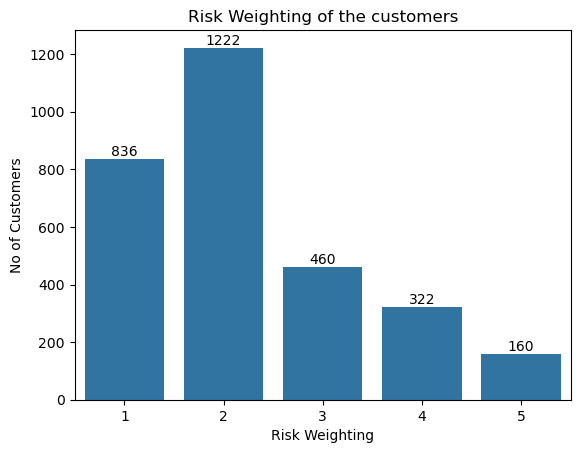

In [86]:
ax=sns.barplot(risk_customer,x="Risk Weighting",y="Client ID")
ax.bar_label(ax.containers[0])
plt.ylabel("No of Customers")
plt.title("Risk Weighting of the customers")
plt.show()

12. Do customers with higher bank loans have higher risk weightings?

C:\Users\Shravan Kundap\AppData\Local\Temp\ipykernel_35928\1330497440.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


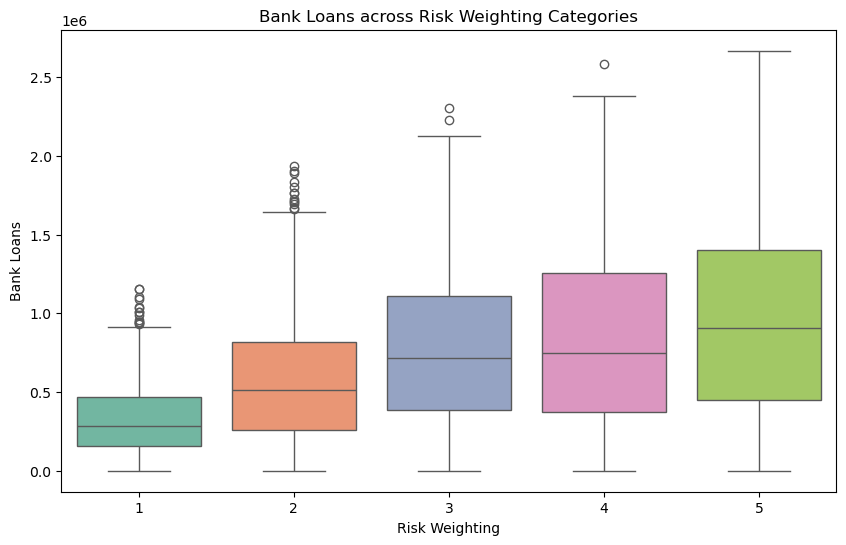

In [87]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Risk Weighting",
    y="Bank Loans",
    palette="Set2"
)

plt.title("Bank Loans across Risk Weighting Categories")
plt.xlabel("Risk Weighting")
plt.ylabel("Bank Loans")

plt.show()

In [89]:
df.to_csv("Bank_Customer_Data_Cleaned.csv", index=False)